In [28]:
import numpy as np 
from openTSNE import affinity, TSNEEmbedding, initialization
from openTSNE.affinity import Affinities  # Import the class
from openTSNE.tsne import TSNE
import matplotlib.gridspec as gridspec

# from openTSNE.callbacks import ErrorLogger
from sklearn.datasets import make_swiss_roll
import matplotlib.pyplot as plt
from dataclasses import dataclass
import seaborn as sns

#from gradient_alpha import gradient_alpha_with_quadtree  # Import optimized function
#from quad_tree import QuadTree

# Optimisation of DoF (Alpha) parameter for T-SNE

## Necessary functions

$$
\boxed {q_{i,j} = \dfrac{\left(1 + \dfrac{d_{i,j}^2}{\alpha}\right)^{-\alpha}}{\sum_{k \ne \ell} \left(1 + \dfrac{d_{k,\ell}^2}{\alpha}\right)^{-\alpha}} }
$$

In [30]:
def compute_low_dim_affinities(
    Y: np.ndarray | TSNEEmbedding, α: float
) -> tuple[np.ndarray, np.ndarray]:
    """Computes the joint distribution of the embedded points Q (q_i_j) in the low-dimensional space.

    Parameters
    ----------
    Y: np.ndarray | TSNE.Embedding
        The low-dimensional representation of the data.
    alpha: float
        The degree-of-freedom parameter of the t-SNE algorithm.

    Returns
    -------
    Q: np.ndarray
        The joint probability distribution of the embedded points.
    distances: np.ndarray
        The pairwise squared distances between all points in the low-dimensional space.

    """
    Y = np.asarray(Y) # Convert to numpy array
    #n = Y.shape[0]

    # Optimized squared distance computation
    sum_Y = np.sum(np.square(Y), 1)
    distances = -2.0 * np.dot(Y, Y.T)
    distances = np.add(np.add(distances, sum_Y).T, sum_Y)

    num = (1.0 + distances/α) ** -(α) # not forget to divide by α
    np.fill_diagonal(num, 0.0)
    
    #num[range(n), range(n)] = 0.0
    Q = num / np.sum(num)
    Q = np.maximum(Q, 1e-12)
    

    return Q, distances


$$
\boxed{\frac{\partial L}{\partial \alpha} = \sum_{i,j} \left( p_{i,j} - q_{i,j} \right) \left( \log \left( 1 + \dfrac{d_{i,j}^2}{\alpha} \right) - \dfrac{d_{i,j}^2}{\alpha + d_{i,j}^2} \right)}.
$$

In [29]:
def compute_gradient_alpha_exact(p: Affinities | np.ndarray, d_squared: np.ndarray, α: float) -> float:
    """Compute the gradient of the t-SNE loss function (KL) with respect to the degree-of-freedom parameter α.

    Parameters
    ----------
    p : Affinities | np.ndarray
        The input openTSNE affinities object or a numpy array containing the affinities matrix.
    d_squared : np.ndarray
        The pairwise squared distances between all points in the low-dimensional space.

    Returns
    -------
    gradient : float
        The gradient of the t-SNE loss function with respect to α.
    """

    # Ensure inputs are numpy arrays
    p = np.array(p)
    d_squared = np.array(d_squared)

    s = 1 + d_squared / α
    
    num = s ** (-α) # numerator

    Z = np.sum(num) # normalization factor

    q = num / Z

    log_s = np.log(s)

    frac = d_squared / (α + d_squared)

    diff = p - q

    gradient_components = diff * (log_s - frac)

    gradient = np.sum(gradient_components)

    return gradient


In [ ]:
@dataclass
class TSNEResult:
    """Dataclass to store the results of a single t-SNE algorithm run."""
    dataset_name: str
    n_samples: int
    n_iter: int
    embedding: np.ndarray
    optimization_mode: str | None
    kl_divergence: float
    initial_alpha: float
    alpha_lr: float
    im_embeddings: list
    im_KLs: np.ndarray
    im_alphas: np.ndarray
    im_alpha_grads: np.ndarray

In [ ]:
def tsne_with_dof_optimisation(
    X: np.ndarray,
    n_iter: int,
    initial_alpha: float,
    alpha_lr: float,
    dataset_name: str,
    optimise_for_alpha: str | None = None,
    verbose: bool = True,
) -> TSNEResult:
    """
    Parameters
    ----------
    X : np.ndarray
        The data to be embedded.
    n_iter : int
        The number of iterations to run the t-SNE algorithm.
    initial_alpha : float
        The initial degree-of-freedom parameter of the t-SNE algorithm.
    alpha_lr : float
        The learning rate for the optimization of the degree-of-freedom parameter.
    dataset_name : str
        The name of the dataset.
    optimise_for_alpha : str, optional
        The mode of optimization for the degree-of-freedom parameter. If None, the parameter is not optimized. By default None.
    verbose : bool, optional
        Whether to print the progress of the algorithm. By default True.

    Returns
    -------
    TSNEResult
        A dataclass containing the results of the t-SNE algorithm
    """

    # store the intermediaries
    embeddings = []
    alphas = np.full(n_iter, float(initial_alpha))
    alpha_grads = np.zeros(n_iter)
    KLs = np.zeros(n_iter)

    n_samples = X.shape[0]
    # define the tsne workflow
    tsne_workflow = TSNE(
        n_components=2, perplexity=30, random_state=0, dof=initial_alpha
    )

    # step 1: compute the affinity matrix
    print("Computing the affinity matrix...")
    affinities_obj = affinity.PerplexityBasedNN(
        X, perplexity=30, metric="euclidean", n_jobs=1, random_state=0
    )

    affinity_matrix = affinities_obj.P.toarray()
    affinity_matrix = np.maximum(affinity_matrix, 1e-12)

    # step 2: perfrom the pca initialization
    print("Performing the PCA initialization...")
    pca_init = initialization.pca(X, random_state=0)

    # step 3: initialize the tsne embedding
    print("Initializing the t-SNE embedding...")
    embedding = tsne_workflow.prepare_initial(
        X=X, affinities=affinities_obj, initialization=pca_init
    )

    # perform 250 iterations with early exaggeration
    default_exagerration = 12
    default_learning_rate = n_samples / default_exagerration
    default_early_exaggeration_iter = 250

    print(
        f"Performing the early exaggeration fase with exaggeration = {default_exagerration} and learning rate = {default_learning_rate} for {default_early_exaggeration_iter} iterations..."
    )
    embedding.optimize(
        default_early_exaggeration_iter,
        exaggeration=default_exagerration,
        learning_rate=default_learning_rate,
        inplace=True,
        dof=initial_alpha,
    )

    # Optimize
    print(f"Running optimization for {n_iter} iterations...")
    current_alpha = initial_alpha

    for i in range(n_iter):
        KLs[i] = embedding.kl_divergence

        if optimise_for_alpha == "gradient_descent":
            Q, sqr_distances = compute_low_dim_affinities(Y=embedding, α=current_alpha)

            # Compute the gradient w.r.t. alpha
            grad_alpha = compute_gradient_alpha_exact(p=affinity_matrix, d_squared=sqr_distances, α=current_alpha)

            # Update alpha
            current_alpha -= alpha_lr * grad_alpha

            alpha_grads[i] = grad_alpha

            embedding.optimize(1, inplace=True, dof=current_alpha)

        elif optimise_for_alpha == "drift" and i > 0:
            if alpha_lr > 0.1:
                print(
                    "Learning rate is too high for drift optimization. Please choose a smaller learning rate"
                )
            Q, distances = compute_low_dim_affinities(
                embedding, current_alpha + alpha_lr
            )

            im_embedding = embedding.optimize(
                1, inplace=False, dof=current_alpha + alpha_lr
            )
            kl = im_embedding.kl_divergence
            if kl < KLs[i - 1]:
                current_alpha += alpha_lr

            else:
                current_alpha -= alpha_lr

            embedding.optimize(1, inplace=True, dof=current_alpha)

        elif not optimise_for_alpha or optimise_for_alpha == "none":
            # Optimize the embedding
            embedding.optimize(1, inplace=True, dof=current_alpha)

        # store the intermediaries
        embeddings.append(embedding)

        alphas[i] = current_alpha

        if verbose:
            print(f"Iteration {i} out of {n_iter} done")
            print(f"Current KL divergence: {KLs[i]}")
            print(f"Current alpha: {current_alpha}")
            print(f"Current alpha gradient: {alpha_grads[i]}")
            print("-----------------------------------")

    return TSNEResult(
        n_iter=n_iter,
        embedding=embedding,
        kl_divergence=embedding.kl_divergence,
        initial_alpha=initial_alpha,
        alpha_lr=alpha_lr,
        im_embeddings=embeddings,
        im_KLs=KLs,
        im_alphas=alphas,
        im_alpha_grads=alpha_grads,
        dataset_name=dataset_name,
        n_samples=n_samples,
        optimization_mode=optimise_for_alpha,
    )


In [6]:
def plot_tsne_result(data: TSNEResult, labels):
    fig = plt.figure(figsize=(10, 8))

    # set up axes
    gs = gridspec.GridSpec(2, 3, height_ratios=[1, 0.4])
    ax1 = fig.add_subplot(gs[0, :])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[1, 1])
    ax4 = fig.add_subplot(gs[1, 2])

    ax1.scatter(data.embedding[:, 0], data.embedding[:, 1], c=labels)
    ax1.set_xticks([])
    ax1.set_yticks([])
    sns.despine(bottom=True, left=True, ax=ax1)

    ax2.plot(data.im_KLs, color="blue")
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("KL divergence", color="blue")
    sns.despine(bottom=False, left=False, ax=ax2)

    ax3.plot(data.im_alphas, color="red")
    ax3.set_xlabel("Iteration")
    ax3.set_ylabel("alpha", color="red")
    sns.despine(bottom=False, left=False, ax=ax3)

    ax4.plot(data.im_alpha_grads, color="green", label="alpha gradient")
    ax4.hlines(0, 0, data.n_iter, color="red", linestyle="--", label="zero gradient")
    ax4.set_xlabel("Iteration")
    ax4.set_ylabel("alpha gradient", color="green")
    sns.despine(bottom=False, left=False, ax=ax4)

    # format the f-string to 2 decimal places
    # {data.kl_divergence:.2f}

    if data.optimization_mode:
        title_param_1 = 'adaptive'
        title_param_2 = f'Initial alpha = {data.initial_alpha}. Alpha learning rate = {data.alpha_lr}'
        title_param_3 = f'Final alpha = {data.im_alphas[-1]:.2f}. Final Loss = {data.kl_divergence:.2f}'
    else:
        title_param_1 = 'fixed'
        title_param_2 = f'Alpha = {data.initial_alpha}. Final Loss = {data.kl_divergence:.2f}'
        title_param_3 = ''

    plt.suptitle(
        f"t-SNE embedding with {title_param_1} degrees of freedom\n{data.dataset_name} with {data.n_samples} samples\n{title_param_2}\n{title_param_3}",fontsize = 12, fontweight = "bold", color = "black"
    )

    plt.tight_layout()
    plt.show()


def plot_side_by_side(data1: TSNEResult, data2: TSNEResult, labels):
    fig = plt.figure(figsize=(16, 8))

    # set up axes
    gs = gridspec.GridSpec(2, 6, height_ratios=[1, 0.4])

    # plot the first embedding

    ax1_1 = fig.add_subplot(gs[0, :3])
    ax1_2 = fig.add_subplot(gs[1, 0])
    ax1_3 = fig.add_subplot(gs[1, 1])
    ax1_4 = fig.add_subplot(gs[1, 2])

    ax1_1.scatter(data1.embedding[:, 0], data1.embedding[:, 1], c=labels)
    ax1_1.set_xticks([])
    ax1_1.set_yticks([])

    if data1.optimization_mode:
        title_param_1 = 'adaptive'
        title_param_2 = f'Initial alpha = {data1.initial_alpha}. Alpha learning rate = {data1.alpha_lr}'
        title_param_3 = f'Final alpha = {data1.im_alphas[-1]:.2f}. Final Loss = {data1.kl_divergence:.2f}'
    else:
        title_param_1 = 'fixed'
        title_param_2 = f'Alpha = {data1.initial_alpha}. Final Loss = {data1.kl_divergence:.2f}'
        title_param_3 = ''
    
    ax1_1.set_title(
        f"t-SNE embedding with {title_param_1} degrees of freedom\n{data1.dataset_name} with {data1.n_samples} samples\n{title_param_2}\n{title_param_3}",
        fontsize=12,
        fontweight="bold",
        color="black",
    )

    sns.despine(bottom=True, left=True, ax=ax1_1)

    ax1_2.plot(data1.im_KLs, color="blue")
    ax1_2.set_xlabel("Iteration")
    ax1_2.set_ylabel("KL divergence", color="blue")
    sns.despine(bottom=False, left=False, ax=ax1_2)

    ax1_3.plot(data1.im_alphas, color="red")
    ax1_3.set_xlabel("Iteration")
    ax1_3.set_ylabel("alpha", color="red")
    sns.despine(bottom=False, left=False, ax=ax1_3)

    ax1_4.plot(data1.im_alpha_grads, color="green", label="alpha gradient")
    ax1_4.hlines(0, 0, data1.n_iter, color="red", linestyle="--", label="zero gradient")
    ax1_4.set_xlabel("Iteration")
    ax1_4.set_ylabel("alpha gradient", color="green")
    sns.despine(bottom=False, left=False, ax=ax1_4)

    # plot the second embedding

    ax2_1 = fig.add_subplot(gs[0, 3:])
    ax2_2 = fig.add_subplot(gs[1, 3])
    ax2_3 = fig.add_subplot(gs[1, 4])
    ax2_4 = fig.add_subplot(gs[1, 5])

    ax2_1.scatter(data2.embedding[:, 0], data2.embedding[:, 1], c=labels)
    ax2_1.set_xticks([])
    ax2_1.set_yticks([])

    if data2.optimization_mode:
        title_param_1 = 'adaptive'
        title_param_2 = f'Initial alpha = {data2.initial_alpha}. Alpha learning rate = {data2.alpha_lr}'
        title_param_3 = f'Final alpha = {data2.im_alphas[-1]:.2f}. Final Loss = {data2.kl_divergence:.2f}'
    else:
        title_param_1 = 'fixed'
        title_param_2 = f'Alpha = {data2.initial_alpha}. Final Loss = {data2.kl_divergence:.2f}'
        title_param_3 = ''

    ax2_1.set_title(
        f"t-SNE embedding with {title_param_1} degrees of freedom\n{data2.dataset_name} with {data2.n_samples} samples\n{title_param_2}\n{title_param_3}", fontsize = 12, fontweight = "bold", color = "black")

    sns.despine(bottom=True, left=True, ax=ax2_1)

    ax2_2.plot(data2.im_KLs, color="blue")
    ax2_2.set_xlabel("Iteration")
    ax2_2.set_ylabel("KL divergence", color="blue")
    sns.despine(bottom=False, left=False, ax=ax2_2)

    ax2_3.plot(data2.im_alphas, color="red")
    ax2_3.set_xlabel("Iteration")
    ax2_3.set_ylabel("alpha", color="red")
    sns.despine(bottom=False, left=False, ax=ax2_3)

    ax2_4.plot(data2.im_alpha_grads, color="green", label="alpha gradient")
    ax2_4.hlines(0, 0, data2.n_iter, color="red", linestyle="--", label="zero gradient")
    ax2_4.set_xlabel("Iteration")
    ax2_4.set_ylabel("alpha gradient", color="green")
    sns.despine(bottom=False, left=False, ax=ax2_4)

    plt.tight_layout()

    # Enable LaTeX rendering

    plt.show()

## Swiss Role with 500 data-points

In [7]:
X, _ = make_swiss_roll(n_samples=500, noise=0, random_state=0)

### 1. Comparison of the openTSNE embedding with the custom implementation with a fixed DoF

In [26]:
affinities = affinity.PerplexityBasedNN(
    X, perplexity=30, metric="euclidean", n_jobs=1, random_state=0
)

print(type(affinities))

init = initialization.pca(X, random_state=0)
tsne_result_1 = TSNE(
    n_components=2, perplexity=30, random_state=0, dof=1, verbose=True, n_iter=1000
).fit(X=X, initialization=init, affinities=affinities)

tsne_result_1_no_opt_open_tsne = TSNEResult(
    dataset_name="Swiss roll",
    n_samples=500,
    n_iter=1000,
    embedding=tsne_result_1,
    optimization_mode=None,
    kl_divergence=tsne_result_1.kl_divergence,
    initial_alpha=1,
    alpha_lr=0,
    im_embeddings=[],
    im_KLs=np.zeros(1000),
    im_alphas=np.ones(1000),
    im_alpha_grads=np.zeros(1000),
)


<class 'openTSNE.affinity.PerplexityBasedNN'>
--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_iter=1000, random_state=0, verbose=True)
--------------------------------------------------------------------------------
===> Running optimization with exaggeration=12.00, lr=83.33 for 250 iterations...
Iteration   50, KL divergence 2.4935, 50 iterations in 1.0972 sec
Iteration  100, KL divergence 2.5969, 50 iterations in 1.1437 sec


KeyboardInterrupt: 

In [9]:
tsne_result_1_no_opt_custom = tsne_with_dof_optimisation(X, n_iter = 1000, initial_alpha = 1, alpha_lr = 0.1, dataset_name = 'Swiss roll', verbose = True)

Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 1000 iterations...
Iteration 0 out of 1000 done
Current KL divergence: 2.365290417147051
Current alpha: 1
Current alpha gradient: 0.0
-----------------------------------
Iteration 1 out of 1000 done
Current KL divergence: 1.9486485287915905
Current alpha: 1
Current alpha gradient: 0.0
-----------------------------------
Iteration 2 out of 1000 done
Current KL divergence: 1.5255771124082536
Current alpha: 1
Current alpha gradient: 0.0
-----------------------------------
Iteration 3 out of 1000 done
Current KL divergence: 1.2313276057735578
Current alpha: 1
Current alpha gradient: 0.0
-----------------------------------
Iteration 4 out of 1000 done
Current KL divergence: 1.027213108911866
Current alpha: 1
Current alpha gradient: 0.0
-----

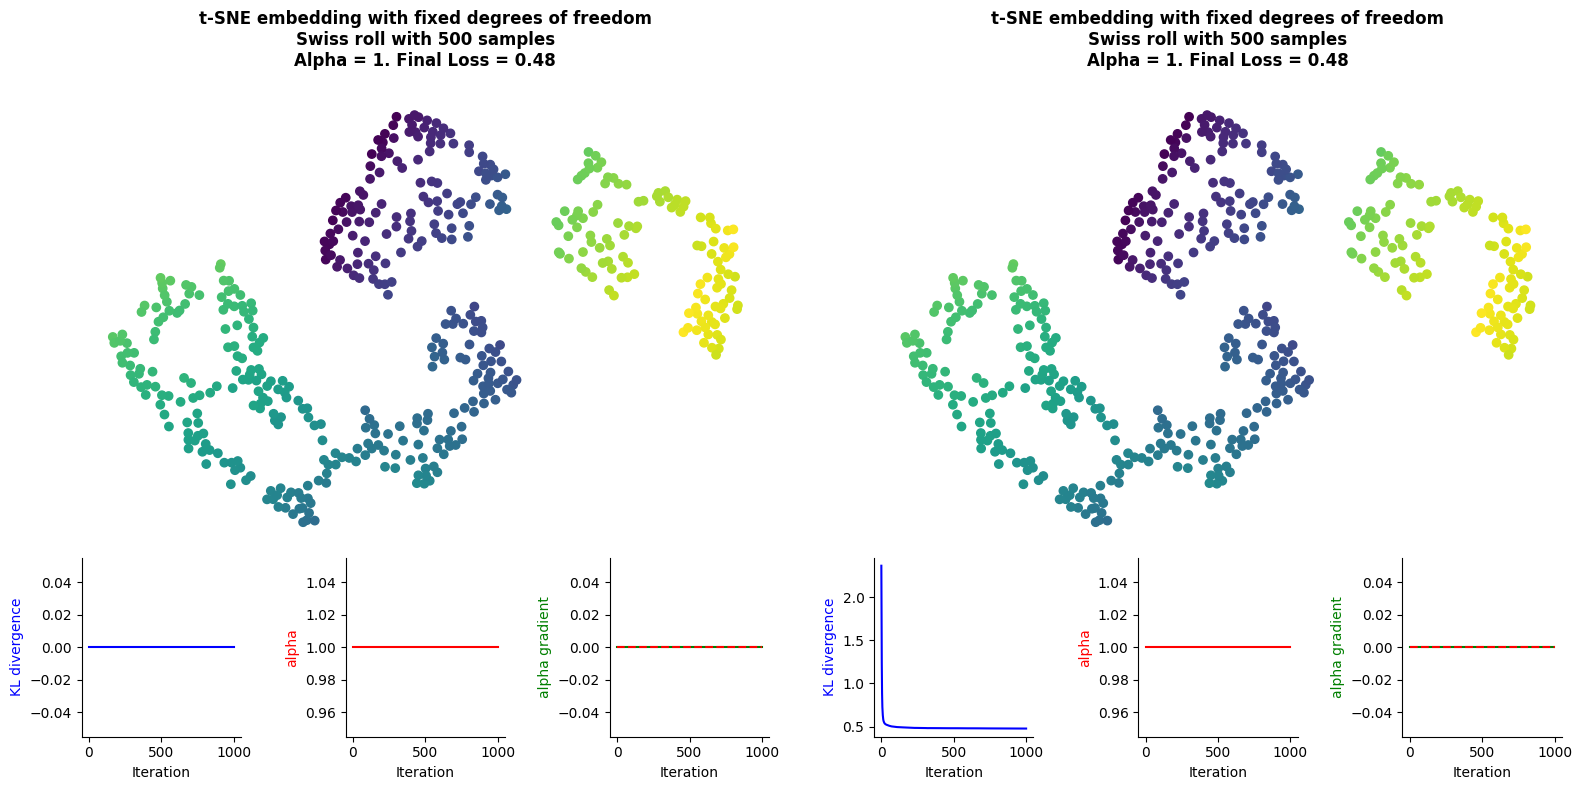

In [10]:
plot_side_by_side(tsne_result_1_no_opt_open_tsne, tsne_result_1_no_opt_custom, _)

### 2. Perfroming the custom implementation with an adaptive DoF

In [11]:
tsne_result_1_opt = tsne_with_dof_optimisation(X, n_iter = 1000, initial_alpha = 1, alpha_lr = 0.5, verbose = True, dataset_name = 'Swiss Roll', optimise_for_alpha = 'gradient_descent')

Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 1000 iterations...
Iteration 0 out of 1000 done
Current KL divergence: 2.365290417147051
Current alpha: 1.048739705122945
Current alpha gradient: -0.09747941024589007
-----------------------------------
Iteration 1 out of 1000 done
Current KL divergence: 1.9291782222683835
Current alpha: 1.184280272750197
Current alpha gradient: -0.27108113525450434
-----------------------------------
Iteration 2 out of 1000 done
Current KL divergence: 1.4305321352453237
Current alpha: 1.3688770648086184
Current alpha gradient: -0.3691935841168427
-----------------------------------
Iteration 3 out of 1000 done
Current KL divergence: 1.0347576282921995
Current alpha: 1.5361554041789967
Current alpha gradient: -0.3345566787407565
------------------------

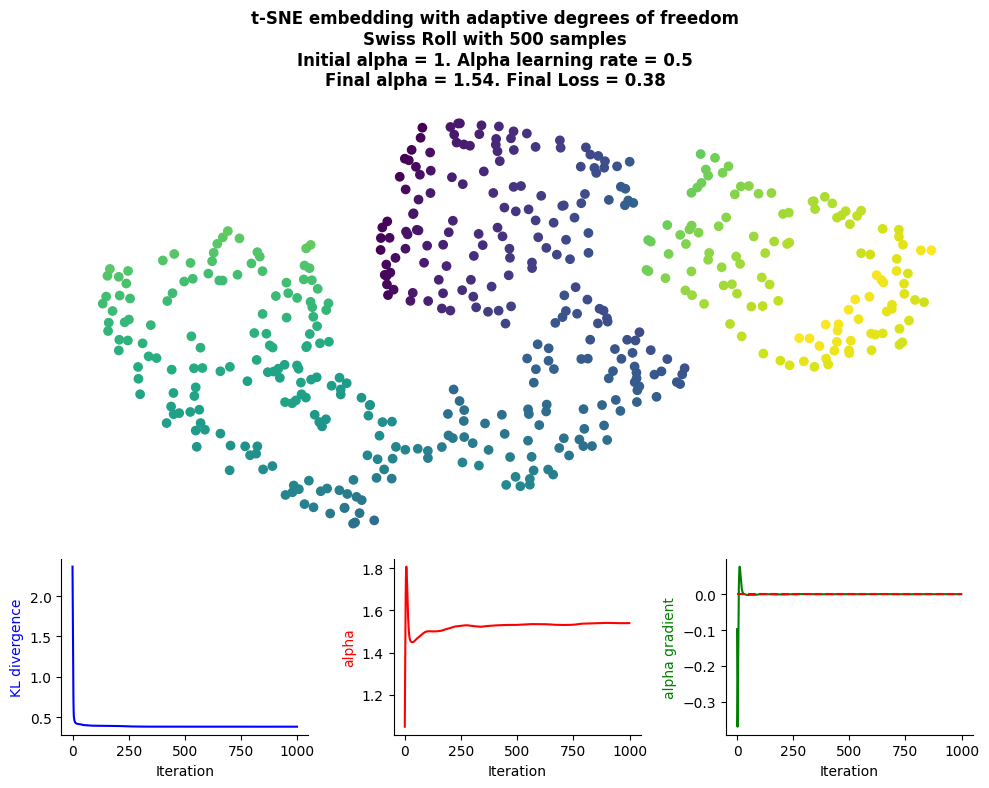

In [12]:
plot_tsne_result(tsne_result_1_opt, _)

### 3. Comparison of performance of the custom implementation with an adaptive DoF and the fixed DoF = 1

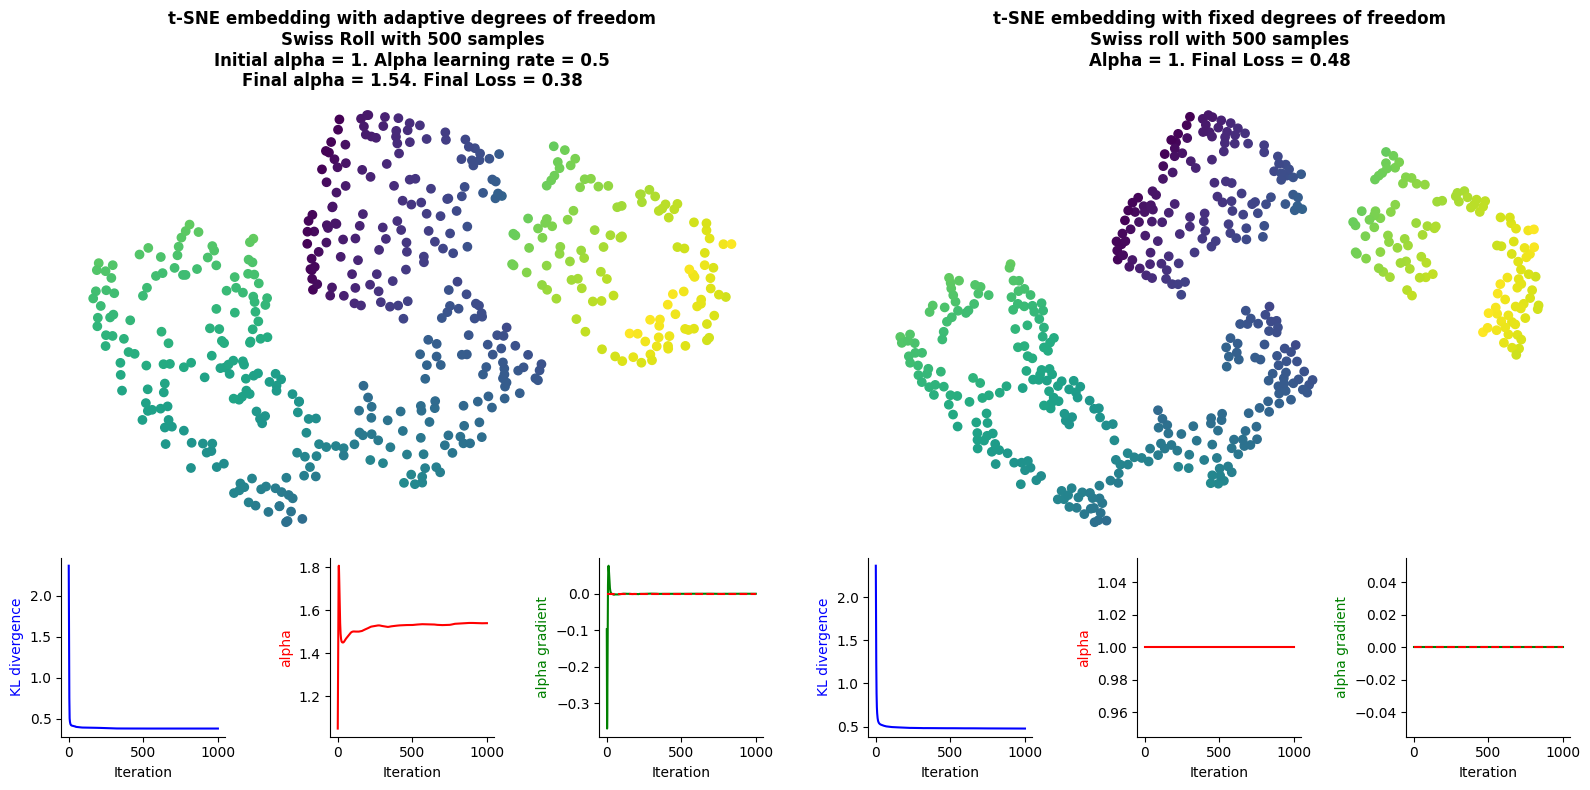

In [13]:
plot_side_by_side(tsne_result_1_opt, tsne_result_1_no_opt_custom, _)

### 4. Comparison of performance of the custom implementation with an adaptive DoF and the fixed DoF = 'optimal' DoF

In [14]:
tsne_result_0_2_5 = tsne_with_dof_optimisation(X, n_iter = 1000, initial_alpha = 1.54, alpha_lr = 0.5, dataset_name = 'Swiss roll', verbose = True)

Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 1000 iterations...
Iteration 0 out of 1000 done
Current KL divergence: 2.2632301596892184
Current alpha: 1.54
Current alpha gradient: 0.0
-----------------------------------
Iteration 1 out of 1000 done
Current KL divergence: 1.7308211300723304
Current alpha: 1.54
Current alpha gradient: 0.0
-----------------------------------
Iteration 2 out of 1000 done
Current KL divergence: 1.2363922540722747
Current alpha: 1.54
Current alpha gradient: 0.0
-----------------------------------
Iteration 3 out of 1000 done
Current KL divergence: 0.9186517552053708
Current alpha: 1.54
Current alpha gradient: 0.0
-----------------------------------
Iteration 4 out of 1000 done
Current KL divergence: 0.7194770220118052
Current alpha: 1.54
Current alpha gr

In [15]:
print(tsne_result_0_2_5.optimization_mode)

None


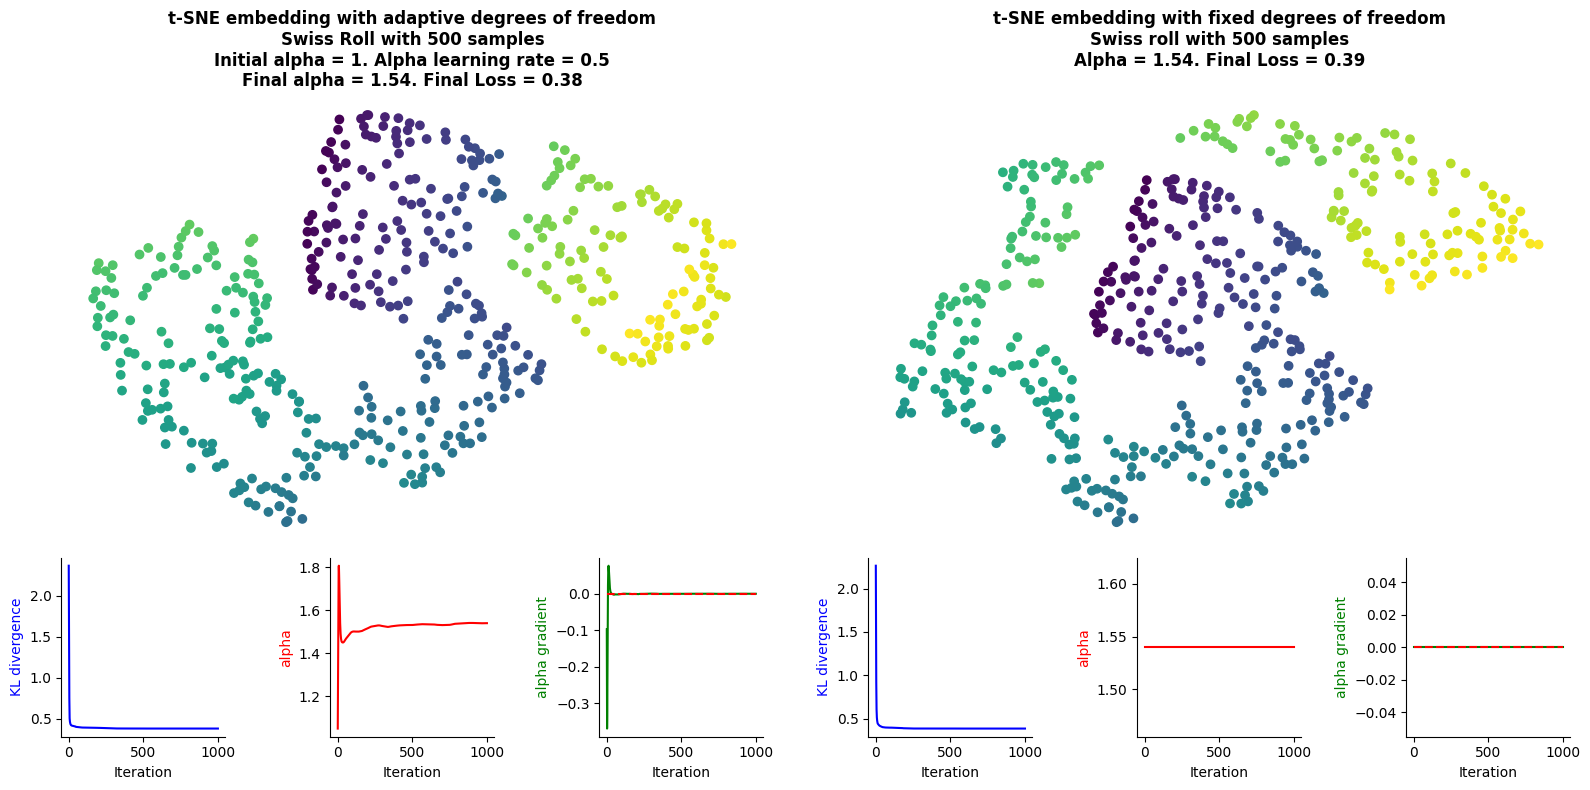

In [16]:
plot_side_by_side(tsne_result_1_opt, tsne_result_0_2_5, _)

#### Setting initial alpha to 5

In [17]:
X, _ = make_swiss_roll(n_samples=500, noise=0, random_state=0)

In [18]:
tsne_result_5_opt = tsne_with_dof_optimisation(X, n_iter = 1000, initial_alpha = 5, alpha_lr = 1, dataset_name = 'Swiss roll', optimise_for_alpha = 'gradient_descent', verbose = True)

Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 1000 iterations...
Iteration 0 out of 1000 done
Current KL divergence: 2.0574663620373723
Current alpha: 5.011647115608113
Current alpha gradient: -0.011647115608113382
-----------------------------------
Iteration 1 out of 1000 done
Current KL divergence: 1.44966100676878
Current alpha: 5.03230718452711
Current alpha gradient: -0.02066006891899675
-----------------------------------
Iteration 2 out of 1000 done
Current KL divergence: 0.9943247101571178
Current alpha: 5.0477085832102135
Current alpha gradient: -0.015401398683103017
-----------------------------------
Iteration 3 out of 1000 done
Current KL divergence: 0.7787276454407337
Current alpha: 5.047892289415279
Current alpha gradient: -0.00018370620506567267
--------------------

In [19]:
tsne_result_5 = tsne_with_dof_optimisation(X, n_iter = 1000, initial_alpha = 5, alpha_lr = 0.05, dataset_name = 'Swiss roll', verbose = True)

Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 1000 iterations...
Iteration 0 out of 1000 done
Current KL divergence: 2.0574663620373723
Current alpha: 5
Current alpha gradient: 0.0
-----------------------------------
Iteration 1 out of 1000 done
Current KL divergence: 1.4500128027068264
Current alpha: 5
Current alpha gradient: 0.0
-----------------------------------
Iteration 2 out of 1000 done
Current KL divergence: 0.9949150268538016
Current alpha: 5
Current alpha gradient: 0.0
-----------------------------------
Iteration 3 out of 1000 done
Current KL divergence: 0.7788713471543272
Current alpha: 5
Current alpha gradient: 0.0
-----------------------------------
Iteration 4 out of 1000 done
Current KL divergence: 0.6561611180027658
Current alpha: 5
Current alpha gradient: 0.0
---

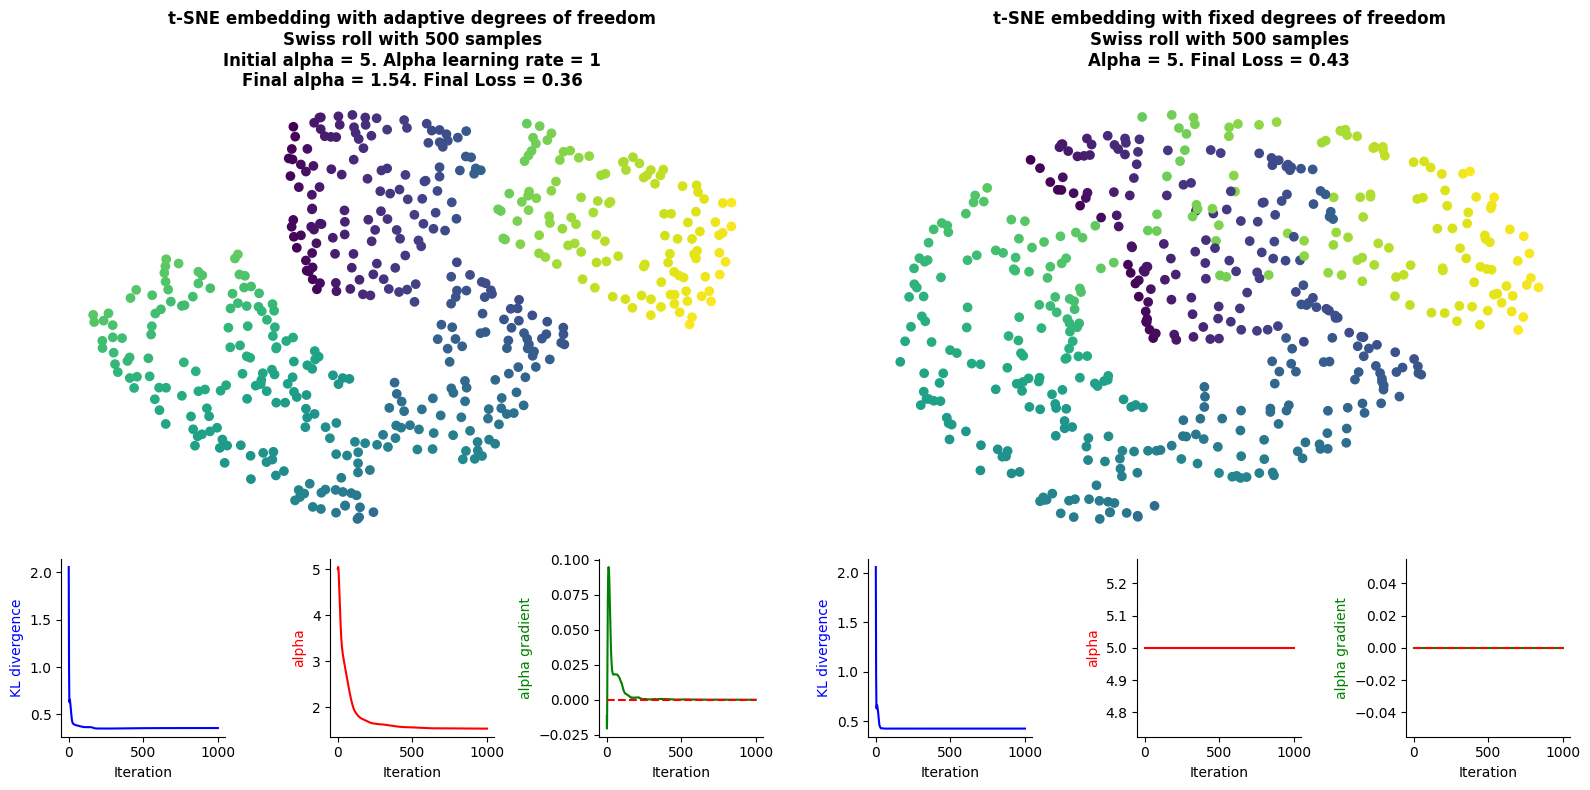

In [20]:
plot_side_by_side(tsne_result_5_opt, tsne_result_5, _)  

In [ ]:
tsne_result_5_final_alpha = tsne_with_dof_optimisation(X, n_iter = 1000, initial_alpha = 1.54, alpha_lr = 0.5, dataset_name = 'Swiss roll', verbose = True)

Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 41.666666666666664 for 250 iterations...
Running optimization for 1000 iterations...
Iteration 0 out of 1000 done
Current KL divergence: 2.131565875088098
Current alpha: 2.96
Current alpha gradient: 0.0
-----------------------------------
Iteration 1 out of 1000 done
Current KL divergence: 1.5152408447284884
Current alpha: 2.96
Current alpha gradient: 0.0
-----------------------------------
Iteration 2 out of 1000 done
Current KL divergence: 1.0081525495457484
Current alpha: 2.96
Current alpha gradient: 0.0
-----------------------------------
Iteration 3 out of 1000 done
Current KL divergence: 0.7549255148053344
Current alpha: 2.96
Current alpha gradient: 0.0
-----------------------------------
Iteration 4 out of 1000 done
Current KL divergence: 0.6304610019171122
Current alpha: 2.96
Current alpha gra

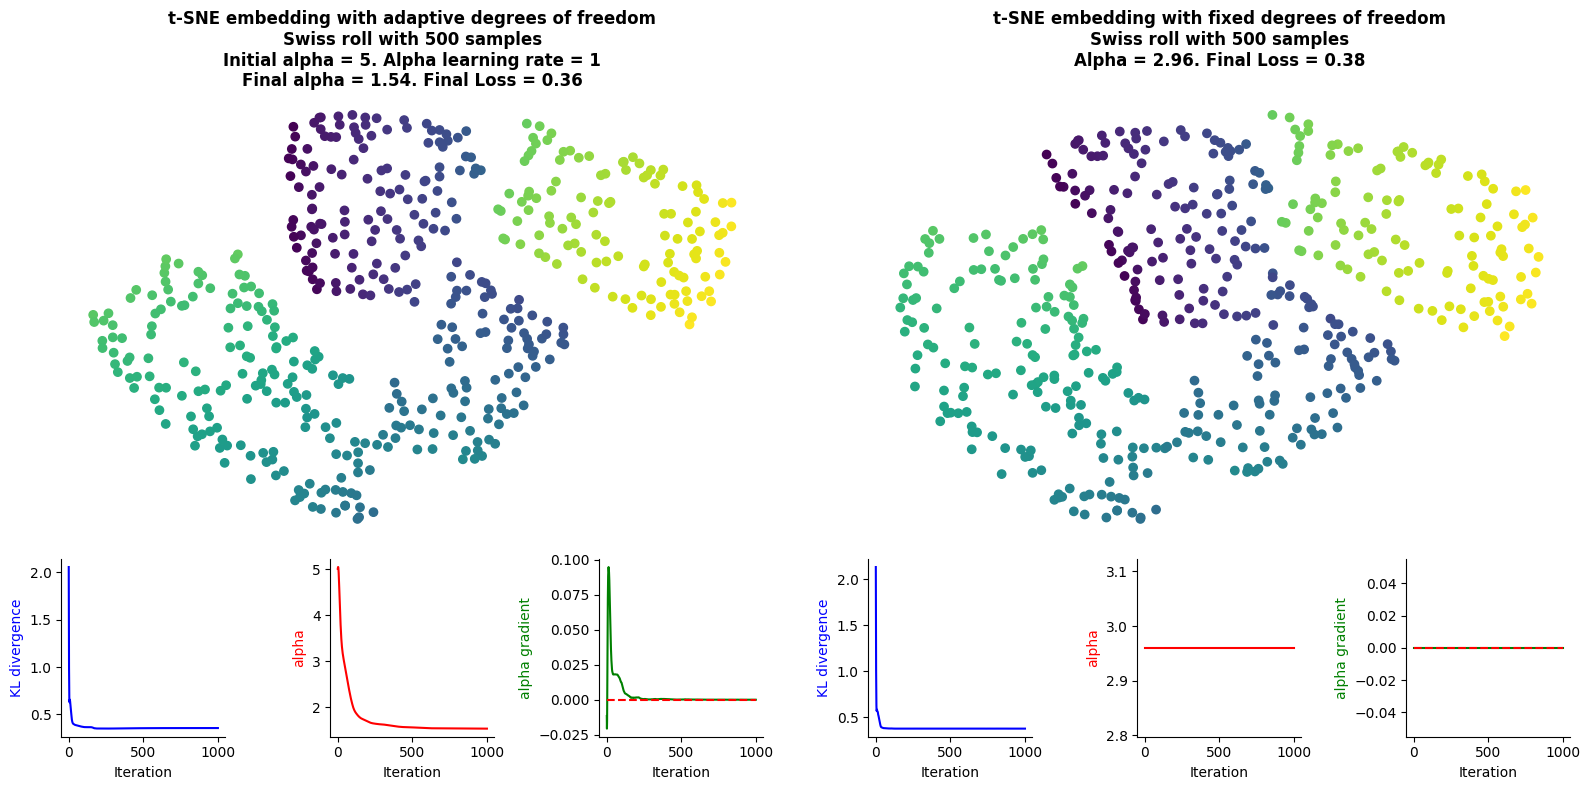

In [22]:
plot_side_by_side(tsne_result_5_opt, tsne_result_5_final_alpha, _)

## Swiss Roll with 1000 data-points

In [23]:
X, colors = make_swiss_roll(n_samples=1000, noise=0, random_state=0)

### 3. Comparison of performance of the custom implementation with an adaptive DoF and the fixed DoF = 1

In [24]:
tsne_result_1000_opt_alpha_1 = tsne_with_dof_optimisation(X, n_iter = 1000, initial_alpha = 1, alpha_lr = 0.5, verbose = True, dataset_name = 'Swiss Roll', optimise_for_alpha = 'gradient_descent')
tsne_result_1000_no_opt_alpha_1 = tsne_with_dof_optimisation(X, n_iter = 1000, initial_alpha = 1, alpha_lr = 0.1, dataset_name = 'Swiss Roll', verbose = True)

Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 83.33333333333333 for 250 iterations...
Running optimization for 1000 iterations...
Iteration 0 out of 1000 done
Current KL divergence: 2.5960897779990457
Current alpha: 1.1441707359145754
Current alpha gradient: -0.2883414718291506
-----------------------------------
Iteration 1 out of 1000 done
Current KL divergence: 2.2762665822635757
Current alpha: 1.3177041198561172
Current alpha gradient: -0.34706676788308355
-----------------------------------
Iteration 2 out of 1000 done
Current KL divergence: 1.8474474649021992
Current alpha: 1.505780991696364
Current alpha gradient: -0.37615374368049365
-----------------------------------
Iteration 3 out of 1000 done
Current KL divergence: 1.4277779423145809
Current alpha: 1.6852606221507795
Current alpha gradient: -0.358959260908831
------------------------

KeyboardInterrupt: 

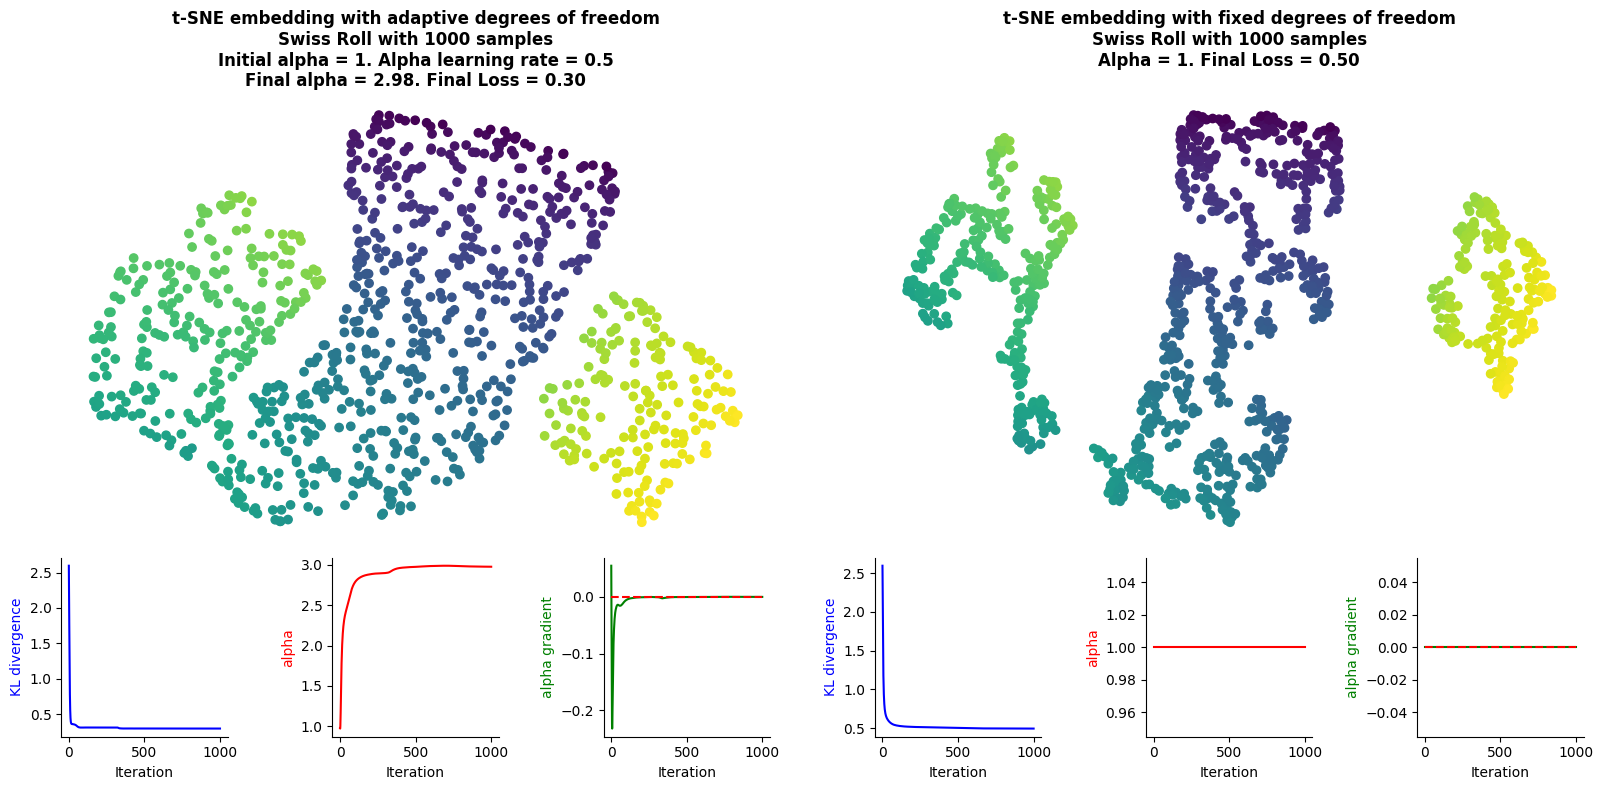

In [ ]:
plot_side_by_side(tsne_result_1000_opt_alpha_1, tsne_result_1000_no_opt_alpha_1, colors)

### 3. Comparison of performance of the custom implementation with an adaptive DoF and the fixed DoF = 'optimal' DoF

In [ ]:
X, colors = make_swiss_roll(n_samples=1000, noise=0, random_state=0)

In [ ]:
tsne_result_1000_no_opt_alpha_2_42 = tsne_with_dof_optimisation(X, n_iter = 1000, initial_alpha = 2.98, alpha_lr = 0.1, dataset_name = 'Swiss Roll', verbose = True)

Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 83.33333333333333 for 250 iterations...
Running optimization for 1000 iterations...
Iteration 0 out of 1000 done
Current KL divergence: 2.2294261631913663
Current alpha: 2.98
Current alpha gradient: 0.0
-----------------------------------
Iteration 1 out of 1000 done
Current KL divergence: 1.7813808139384388
Current alpha: 2.98
Current alpha gradient: 0.0
-----------------------------------
Iteration 2 out of 1000 done
Current KL divergence: 1.2821234814975355
Current alpha: 2.98
Current alpha gradient: 0.0
-----------------------------------
Iteration 3 out of 1000 done
Current KL divergence: 0.9003848372774854
Current alpha: 2.98
Current alpha gradient: 0.0
-----------------------------------
Iteration 4 out of 1000 done
Current KL divergence: 0.6735609725542897
Current alpha: 2.98
Current alpha gra

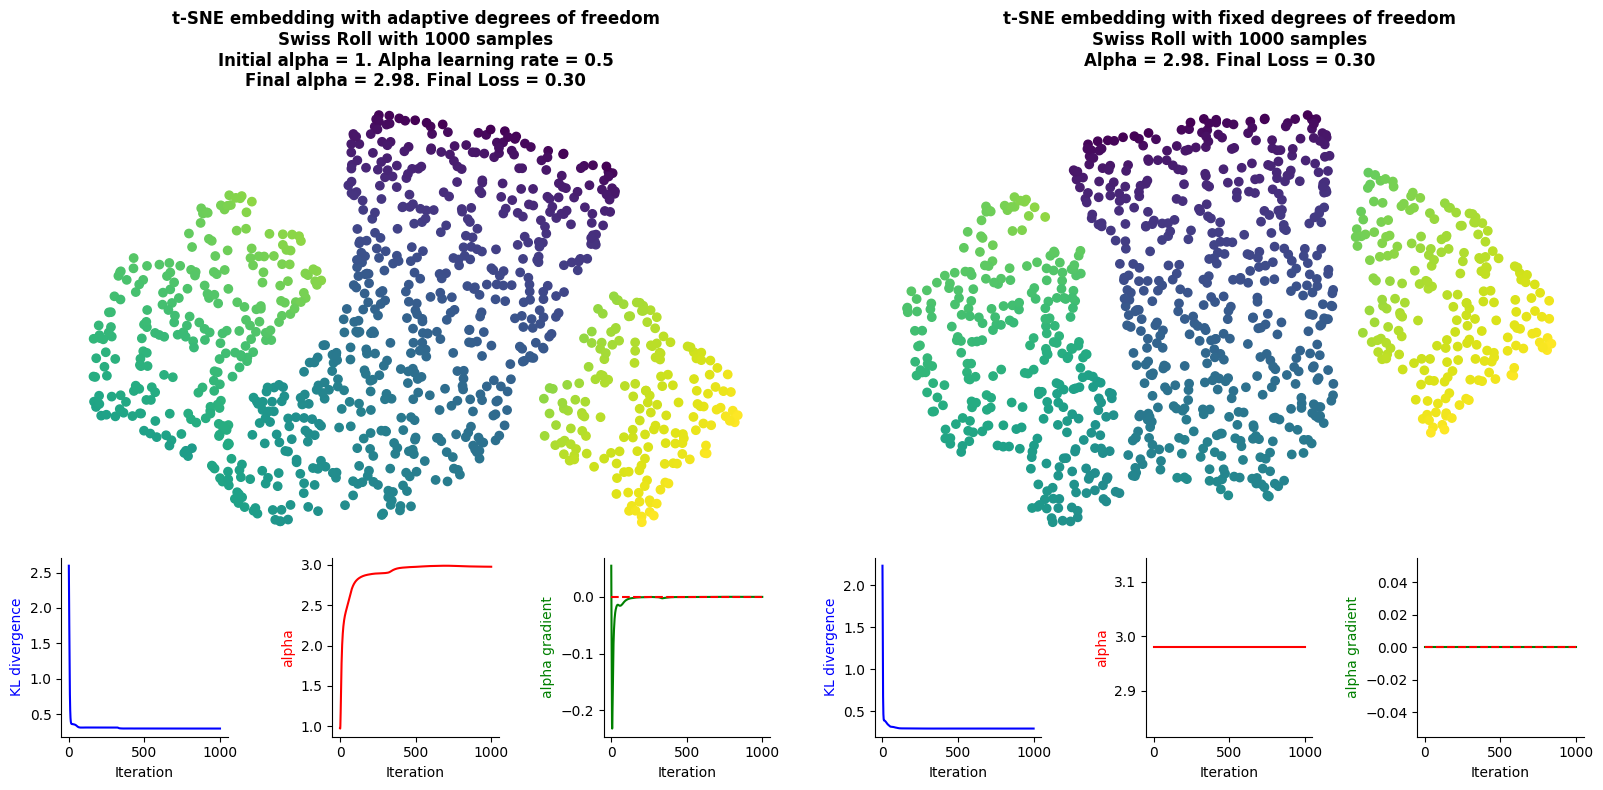

In [ ]:
plot_side_by_side(tsne_result_1000_opt_alpha_1, tsne_result_1000_no_opt_alpha_2_42, colors)

## Swiss Roll with 5000 data-points

In [ ]:
X, colors = make_swiss_roll(n_samples=5000, noise=0, random_state=0)


In [ ]:
tsne_result_5000_opt_alpha_1 = tsne_with_dof_optimisation(X, n_iter = 1000, initial_alpha = 1, alpha_lr = 0.5, verbose = True, dataset_name = 'Swiss Roll')

final_alpha = tsne_result_5000_opt_alpha_1.im_alphas[-1]
tsne_result_5000_no_opt_alpha_final_alpha = tsne_with_dof_optimisation(X, n_iter = 1000, initial_alpha = final_alpha, alpha_lr = 0.1, dataset_name = 'Swiss Roll', verbose = True)

Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 416.6666666666667 for 250 iterations...
Running optimization for 1000 iterations...
Iteration 0 out of 1000 done
Current KL divergence: 2.766980644172282
Current alpha: 1
Current alpha gradient: 0.0
-----------------------------------
Iteration 1 out of 1000 done
Current KL divergence: 2.6603184243684286
Current alpha: 1
Current alpha gradient: 0.0
-----------------------------------
Iteration 2 out of 1000 done
Current KL divergence: 2.50624900600452
Current alpha: 1
Current alpha gradient: 0.0
-----------------------------------
Iteration 3 out of 1000 done
Current KL divergence: 2.3585893275400878
Current alpha: 1
Current alpha gradient: 0.0
-----------------------------------
Iteration 4 out of 1000 done
Current KL divergence: 2.2331817820380913
Current alpha: 1
Current alpha gradient: 0.0
-------

In [ ]:
tsne_result_5000_no_opt_alpha_1 = tsne_with_dof_optimisation(X, n_iter = 1000, initial_alpha = 1, alpha_lr = 0.1, dataset_name = 'Swiss Roll', verbose = True, optimise_for_alpha = 'gradient_descent')

Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 416.6666666666667 for 250 iterations...
Running optimization for 1000 iterations...
Iteration 0 out of 1000 done
Current KL divergence: 2.766980644172282
Current alpha: 1.0146997832561813
Current alpha gradient: -0.14699783256181365
-----------------------------------
Iteration 1 out of 1000 done
Current KL divergence: 2.6450866320018704
Current alpha: 1.0332373796574914
Current alpha gradient: -0.18537596401310114
-----------------------------------
Iteration 2 out of 1000 done
Current KL divergence: 2.467312135317478
Current alpha: 1.057081175864881
Current alpha gradient: -0.23843796207389725
-----------------------------------
Iteration 3 out of 1000 done
Current KL divergence: 2.286891009719925
Current alpha: 1.0862895956881498
Current alpha gradient: -0.2920841982326866
-------------------------

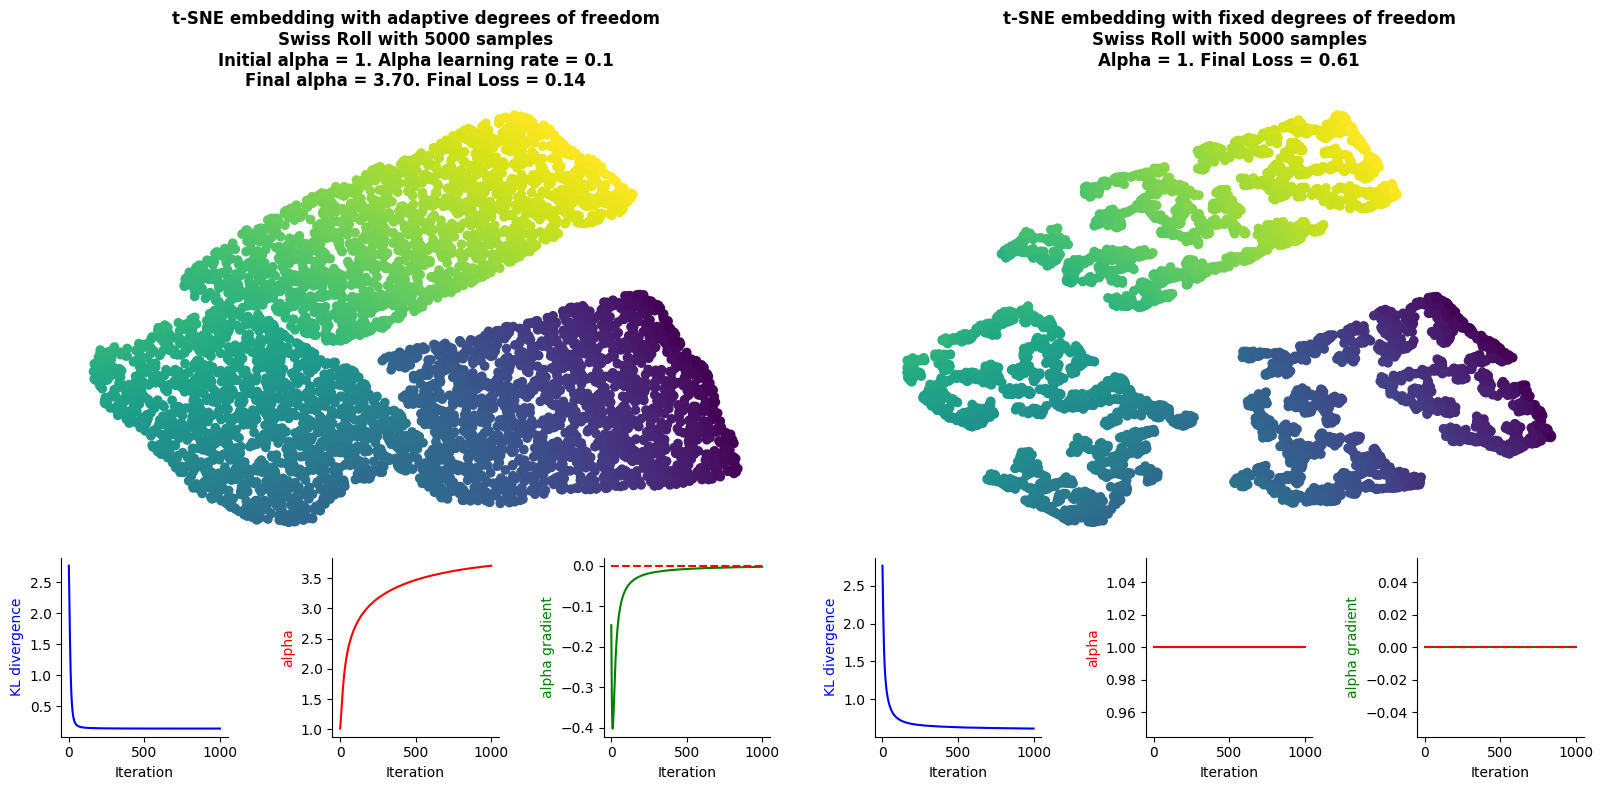

In [ ]:
#plot_side_by_side(tsne_result_5000_opt_alpha_1, tsne_result_5000_no_opt_alpha_1, colors)
plot_side_by_side(tsne_result_5000_no_opt_alpha_1, tsne_result_5000_opt_alpha_1, colors)

In [ ]:
tsne_result_5000_no_opt_alpha_final_alpha = tsne_with_dof_optimisation(X, n_iter = 1000, initial_alpha = 3.7, alpha_lr = 0.1, dataset_name = 'Swiss Roll', verbose = True)

Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...
Performing the early exaggeration fase with exaggeration = 12 and learning rate = 416.6666666666667 for 250 iterations...
Running optimization for 1000 iterations...
Iteration 0 out of 1000 done
Current KL divergence: 1.9385324970886426
Current alpha: 3.7
Current alpha gradient: 0.0
-----------------------------------
Iteration 1 out of 1000 done
Current KL divergence: 1.737877446806607
Current alpha: 3.7
Current alpha gradient: 0.0
-----------------------------------
Iteration 2 out of 1000 done
Current KL divergence: 1.5593146150238066
Current alpha: 3.7
Current alpha gradient: 0.0
-----------------------------------
Iteration 3 out of 1000 done
Current KL divergence: 1.416591354767137
Current alpha: 3.7
Current alpha gradient: 0.0
-----------------------------------
Iteration 4 out of 1000 done
Current KL divergence: 1.2607212686675346
Current alpha: 3.7
Current alpha gradient: 

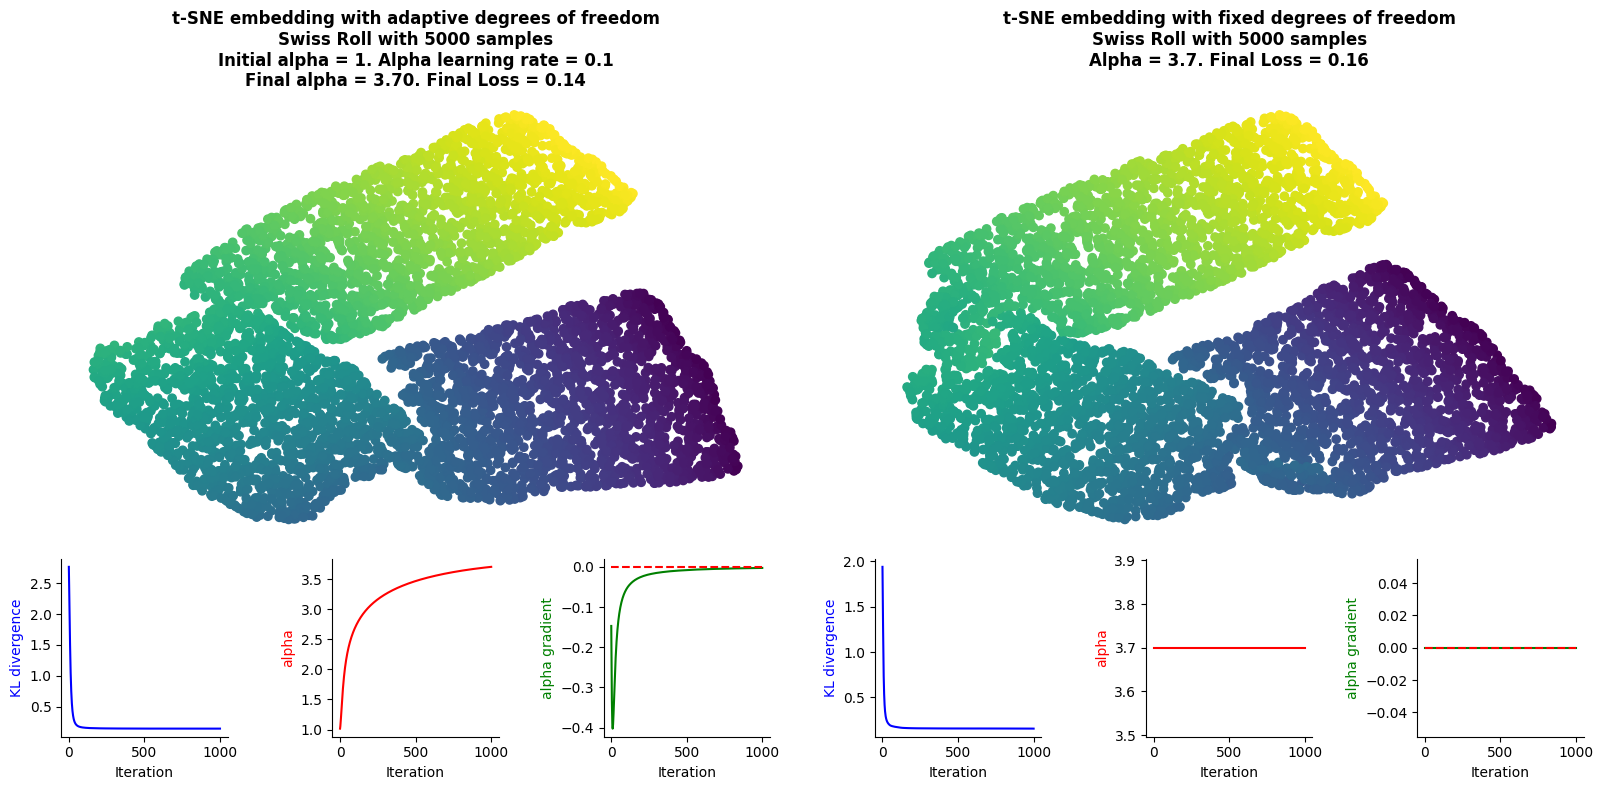

In [ ]:
plot_side_by_side(tsne_result_5000_no_opt_alpha_1, tsne_result_5000_no_opt_alpha_final_alpha, colors)

In [ ]:
# produce error
x=1 
assert x == 2, "x should be 2" 

AssertionError: x should be 2

## Alpha optimization with cython

In [ ]:
X, _ = make_swiss_roll(n_samples=1000, noise=0.2)

### step-by-step

In [ ]:
# step 1: compute affinities
affinity_object = affinity.PerplexityBasedNN(
    X, perplexity=30, metric="euclidean", n_jobs=1, random_state=0
)
affinity_matrix = affinity_object.P.toarray()
print(affinity_matrix.shape)

In [ ]:
# Step 2: Initialize Y
Y = initialization.pca(X, random_state=0)

In [ ]:
# Step 3: Initialize the embedding
initial_alpha = 2
tsne = TSNE(n_components=2, perplexity=30, random_state=0, dof=initial_alpha)
embedding = tsne.prepare_initial(X=X, affinities=affinity_object, initialization=Y)

In [ ]:
# Perform 1 iteration of optimization
embedding.optimize(1, inplace=True, dof=initial_alpha)

In [ ]:
# Perform the loop for 100 iterations
current_alpha = initial_alpha
n_iter = 5000
alphas = []
embeddings = []
KLs = []
embeddings.append(embedding.copy())
for i in range(n_iter):
    # Step 4: Compute pairwise affinities in the low-dimensional space
    Q, distances = compute_pairwise_affinities(embedding, current_alpha)
    #print(distances.shape)
    # Step 5: Compute the gradient w.r.t alpha (with optimized Cython function)
    grad_alpha = gradient_alpha_with_quadtree(
        affinity_matrix,
        Q,
        distances,
        embeddings[-1],
        current_alpha,
    )
    print(grad_alpha)

    # Step 6: Update alpha
    current_alpha -= 0.001 * grad_alpha

    print(f"Iteration {i}: alpha = {current_alpha}")

    # Step 7: Optimize the embedding
    embedding.optimize(1, inplace=True, dof=current_alpha)
    kl = embedding.kl_divergence
    print(f"Iteration {i}: KL = {kl}")

    embeddings.append(embedding.copy())
    alphas.append(current_alpha)
    KLs.append(kl)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].scatter(embedding[:, 0], embedding[:, 1], c=_)
# double y-axis plot
ax[1].plot(KLs, color="blue")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("KL divergence", color="blue")
ax[1].tick_params(axis="y", labelcolor="blue")

ax2 = ax[1].twinx()
ax2.plot(alphas, color="red")
ax2.set_ylabel("alpha", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# set logscale for y-axis
ax2.set_yscale("log")

#ax[1].set_ylim(0.4,3)
plt.show()

In [ ]:
def tsne_with_super_dof_optimisation(X, n_iter, initial_alpha, alpha_lr, start_alpha_optimisation_at_iter=0, verbose = True):
    # store the intermediaries
    embeddings = []
    alphas = []
    KLs = []
    alphas_grad = []
    
    
    # step 1: compute affinities
    print('Computing the affinity matrix...')
    affinity_object = affinity.PerplexityBasedNN(
        X, perplexity=30, metric="euclidean", n_jobs=1, random_state=0
    )
    affinity_matrix = affinity_object.P.toarray()

    # Step 2: Initialize Y
    print('Performing the PCA initialization...')
    Y = initialization.pca(X, random_state=0)
    
    # Step 3: Initialize the embedding
    print('Initializing the t-SNE embedding...')
    tsne = TSNE(n_components=2, perplexity=30, random_state=0, dof=initial_alpha)
    embedding = tsne.prepare_initial(X=X, affinities=affinity_object, initialization=Y)
    # Perform 1 iteration of optimization
    embedding.optimize(1, inplace=True, dof=initial_alpha) 

    

    # Perform the optimization loop
    print('Running optimization...')
    print
    current_alpha = initial_alpha
    for i in range(n_iter):
        
        if i >= start_alpha_optimisation_at_iter:
            
            # Step 4: Compute pairwise affinities in the low-dimensional space
            Q, distances = compute_pairwise_affinities(embedding, current_alpha)

            # Step 5: Compute the gradient w.r.t alpha (with optimized Cython function)
            grad_alpha = gradient_alpha_with_quadtree(
                affinity_matrix,
                Q,
                distances,
                embedding,
                current_alpha,
            )
        #print(grad_alpha)

        # Step 6: Update alpha
        current_alpha -= 0.001 * grad_alpha

        #print(f"Iteration {i}: alpha = {current_alpha}")

        # Step 7: Optimize the embedding
        embedding.optimize(1, inplace=True, dof=current_alpha)
        kl = embedding.kl_divergence

        embeddings.append(embedding.copy())
        alphas.append(current_alpha)
        KLs.append(kl)
        alphas_grad.append(grad_alpha)
        
        if verbose:
            print(f'Iteration {i} out of {n_iter} done')
            print(f'Current KL divergence: {embedding.kl_divergence}')
            print(f'Current alpha: {current_alpha}')
            print(f'Current alpha gradient: {grad_alpha}')
            print('-----------------------------------')
        
    return TSNEResult(n_iter = n_iter, embedding = embedding, kl_divergence = embedding.kl_divergence, im_embeddings = embeddings, im_KLs = KLs, im_alphas = alphas, im_alpha_grads = alphas_grad)

### Swiss Roll 1000 samples 

In [ ]:
X, _ = make_swiss_roll(n_samples=1000, noise=0)

In [ ]:
tsne_result_5 = tsne_with_super_dof_optimisation(X, n_iter = 2000, initial_alpha = 5, alpha_lr = 0.01, start_alpha_optimisation_at_iter=0, verbose = True)

In [ ]:
plot_tsne_result(tsne_result_5)

In [ ]:
tsne_result_6 = tsne_with_super_dof_optimisation(X, n_iter = 2000, initial_alpha = 10, alpha_lr = 0.01, start_alpha_optimisation_at_iter=0, verbose = True)

In [ ]:
plot_tsne_result(tsne_result_6)

In [ ]:
tsne_result_7 = tsne_with_super_dof_optimisation(X, n_iter = 1000, initial_alpha = 0.5, alpha_lr = 100, start_alpha_optimisation_at_iter=0, verbose = True)

In [ ]:
plot_tsne_result(tsne_result_7)

### Swiss Roll 500 samples

In [ ]:
X, _ = make_swiss_roll(n_samples=500, noise=0)

In [ ]:
tsne_result_8 = tsne_with_super_dof_optimisation(X, n_iter = 500, initial_alpha = 1, alpha_lr = 0.01, start_alpha_optimisation_at_iter=0, verbose = True)

In [ ]:
plot_tsne_result(tsne_result_8)

In [ ]:
tsne_result_9 = tsne_with_super_dof_optimisation(X, n_iter = 1000, initial_alpha = 3, alpha_lr = 0.9, start_alpha_optimisation_at_iter=0, verbose = True)

In [ ]:
plot_tsne_result(tsne_result_9)

### Swiss Roll 5000 samples

In [ ]:
X, _ = make_swiss_roll(n_samples=5000, noise=0.0)

In [ ]:
tsne_result_10 = tsne_with_super_dof_optimisation(X, n_iter = 1000, initial_alpha = 1, alpha_lr = 0.9, start_alpha_optimisation_at_iter=0, verbose = True)

In [ ]:
plot_tsne_result(tsne_result_10)